# 从一棵松树读懂 SMX

这份教程写给熟悉字节序、文件存储和《帝国时代 II：决定版》，但没接触过 SMX 的你。我们从 **n_tree_pine_x1.smx 的第 0 帧**出发，沿着“文件里的字节 → 像素位置 → 颜色 → 一棵带阴影的树”走一遍。你不需要先阅读上一份架构报告。

读完后，你应能解释：文件头的数值到底描述什么；为什么一张树图还需要阴影层和锚点；调色板编号与像素索引有什么区别；绘制命令和压缩像素如何配合；哪些游戏信息根本不在这个文件里。

**阅读方式：**文字和实数推导可以直接阅读。从第一段代码依次运行，会看到本地素材的颜色、逐行绘制与对齐预览。正文采用短代码逐步解读，大段完整解析器放在末尾附录。运行时素材图片不会嵌入交付 notebook，教学文字、结构表与验证结果保留。

示例直接读取 reference；开头 MOD_ROOT 可修改。本教程不写入 mod。树桩有意留空，本篇不涉及它们。

In [1]:
from pathlib import Path
from collections import Counter
import struct
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Change this constant to use another local mod.
MOD_ROOT = Path('reference/22014_Anne_HK - Identical Pine Trees with Grid Shadow')
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'reference/reference.md').is_file())
if not MOD_ROOT.is_absolute():
    MOD_ROOT = PROJECT_ROOT / MOD_ROOT
GRAPHICS = MOD_ROOT / 'resources/_common/drs/graphics'
PALETTE_ROOT = PROJECT_ROOT / 'reference/SMX-Workshop/palettes'
SAMPLE_FILE = 'n_tree_pine_x1.smx'
raw = (GRAPHICS / SAMPLE_FILE).read_bytes()

def table(headers: list[str], rows: list) -> None:
    lines = ['| ' + ' | '.join(headers) + ' |',
             '| ' + ' | '.join('---' for _ in headers) + ' |']
    lines += ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in rows]
    display(Markdown('\n'.join(lines)))

print(SAMPLE_FILE, ':', len(raw), 'bytes')

n_tree_pine_x1.smx : 128066 bytes


## 1. 游戏中的树，文件中的 sprite

在游戏里，树能被选中、被采集，还会阻挡单位。SMX 负责其中的**二维图像素材**，也就是 sprite：若干帧，每帧又能保存主图、阴影、轮廓。

可以把每帧想象成围绕同一定位点摆放的几张小纸片。主图纸片画树干和树冠，阴影纸片画地面上的阴影。纸片各自裁剪得尽量小，因此尺寸和左上角位置不同。游戏把它们摆到同一个对象位置，你才看到完整的树。

SMX 没有“这是松树”“剩余木材”“阻挡哪几格”的字段，也没有逐帧时长、FPS 或方向分组字段。对象规则、朝向、动画，以及哪种状态选哪一帧，要结合文件外的游戏数据理解。文件名提供线索，但不属于 SMX 二进制头。

x1/x2 是素材命名中的变体；这里没有一个名叫“一倍缩放”的文件头字段。后面会实际比较这组文件，而不是从名字推断尺寸。

SMX 与早期 SMP 的关系可参考 [openage 格式说明](https://github.com/SFTtech/openage/blob/master/doc/media/smx-files.md)。本教程具体字段与算法以本地 SMX-Workshop 代码和文件实验为依据；SLD 是另一种格式，不能套用这里的字节规则。

## 2. 文件头的语义：哪些数字可以用来定位？

先读前 32 字节，回答“这是哪种格式、总共有多少帧、后面两种大小分别是什么”。

In [2]:
signature, version, frame_count, body_size, smp_size, memo = struct.unpack_from('<4sHHII16s', raw, 0)
assert signature == b'SMPX'
table(['Offset', 'Bytes', 'Field', 'Value'], [
    (0, 4, 'signature', signature.decode('ascii')),
    (4, 2, 'version', version),
    (6, 2, 'frame_count', frame_count),
    (8, 4, 'compressed body size', body_size),
    (12, 4, 'SMP/uncompressed size metadata', smp_size),
    (16, 16, 'memo', memo.rstrip(b'\0').decode('ascii')),
])
assert body_size == len(raw) - 32

| Offset | Bytes | Field | Value |
| --- | --- | --- | --- |
| 0 | 4 | signature | SMPX |
| 4 | 2 | version | 2 |
| 6 | 2 | frame_count | 27 |
| 8 | 4 | compressed body size | 128034 |
| 12 | 4 | SMP/uncompressed size metadata | 103680 |
| 16 | 16 | memo | v1.41 SLX Studio |

### Magic、version 与 memo

**SMPX** 是四字节 magic。扩展名可以改，magic 是解析器在内容中看到的格式证据。名字保留 SMP 的历史痕迹，但不意味着后面内嵌一个完整 SMP 文件。

**version=2** 是文件格式版本，不是游戏版本、mod 版本，也不是“两张图片”。本目录全部 version 2，教程针对这些文件解释。

**memo=v1.41 SLX Studio** 是固定 16 字节备注，可提示制作来源，但不是可靠的工具身份证，也不决定图像颜色。有些文件这段全零；不要假定所有 SMX 都没有备注。

### 两项大小不能都当作实际图片大小

本文件实际长度 **128,066**。compressed body size 为 **128,034**，正好少了 32 字节文件头。它说的是 SMX 文件体长度，不表示整个文件体是一个 zlib/zip 流；后面的结构仍可直接读，像素才使用专门的打包方法。

另一项 **103,680** 被称为 SMP/uncompressed size。它是与 SMP/展开表示相关的生产工具元数据，不是“解压后的一张 RGBA 图片有这么大”。本例每帧的 smp_size=3,840，27×3,840=103,680。这个数字甚至小于 SMX 文件体长度，足见不能直接拿两者计算通用压缩比。

不同写入工具对这项的计算约定不完全一致。我们保留它，却不靠它寻找下一帧；实际游标由字段大小、层高和流长度推进。未知的历史计算原因也不妨碍完整解码。

## 3. 帧：一条记录不必等于一个动画时刻

第一帧从 offset 32 开始，帧头只有六字节。

In [3]:
flags, palette_id, frame_smp_size = struct.unpack_from('<BBI', raw, 32)
table(['Field', 'Value', 'Meaning'], [
    ('flags', f'0x{flags:02X} / {flags:08b}', 'layer presence and pixel packing'),
    ('palette_id', palette_id, 'external palette identifier'),
    ('frame_smp_size', frame_smp_size, 'SMP-related frame size metadata'),
])
table(['Mask', 'Meaning', 'Set here?'], [
    ('0x01', 'main image', bool(flags & 1)),
    ('0x02', 'shadow', bool(flags & 2)),
    ('0x04', 'outline', bool(flags & 4)),
    ('0x08', '8to5 pixel packing', bool(flags & 8)),
])

| Field | Value | Meaning |
| --- | --- | --- |
| flags | 0x03 / 00000011 | layer presence and pixel packing |
| palette_id | 30 | external palette identifier |
| frame_smp_size | 3840 | SMP-related frame size metadata |

| Mask | Meaning | Set here? |
| --- | --- | --- |
| 0x01 | main image | True |
| 0x02 | shadow | True |
| 0x04 | outline | False |
| 0x08 | 8to5 pixel packing | False |

flags=3，即 **0b00000011**：主图、阴影存在，轮廓不存在；0x08 为零，所以主图使用 4plus1。这里的有效掩码从低位递增：1、2、4、8。公开文档中有位号表与示例冲突的情况，不能只照抄位号。

**palette_id=30 不表示所有像素都是第 30 种颜色。**它选择整张外部调色板，各像素再从这张表选择自己的颜色。我们很快会看到这个两级引用。

frame_smp_size=3,840 也不是下一帧的相对偏移。实际第一帧的 SMX 编码长 4,742 字节，下一帧从 offset 4,774 开始。

另有 0x10 的接收其他对象阴影标志；公开说明提供这种语义，但本目录未出现，不能靠这个例子验证游戏效果。

文件里有 **27 帧**。等解析完所有记录，我们会直接比较它们，而不是擅自解释成“27 个动画时刻”。

## 4. 图层头：尺寸、锚点与长度各自解决什么问题？

帧头结束后，主图层头从 offset 38 开始。它的前八字节表示尺寸和锚点。

In [4]:
w, h, hx, hy, declared_length, unknown = struct.unpack_from('<HHhhII', raw, 38)
table(['Field', 'Value', 'Meaning'], [
    ('width / height', f'{w} / {h}', 'local image rectangle in pixels'),
    ('hotspot x / y', f'{hx} / {hy}', 'registration point in local image coordinates'),
    ('payload length', declared_length, 'bytes after this 16-byte layer header'),
    ('unknown', unknown, 'preserved field; meaning not established'),
])

| Field | Value | Meaning |
| --- | --- | --- |
| width / height | 33 / 74 | local image rectangle in pixels |
| hotspot x / y | 16 / 71 | registration point in local image coordinates |
| payload length | 2205 | bytes after this 16-byte layer header |
| unknown | 0 | preserved field; meaning not established |

### 为什么主图 33×74，阴影却是 94×69？

主图需要包住树冠和树干，阴影还包括地面上展开的网格与阴影形状。它们不共享一个固定大小的画布，各自用适合自己的矩形存储。33×74 是**图像像素尺寸**，不是游戏地图的占地格数，也不等于物体碰撞范围。

### hotspot 是定位点，不是自动计算的几何中心

主图 hotspot=(16,71)，明显靠近图片底部。这与把树放到地面上的需要相符，但从二进制本身不能证明它是哪一个游戏逻辑点。解析时只需要它的坐标语义：

若对象在屏幕上的定位点是 (screen_x,screen_y)，局部像素 (x,y) 被放到：

~~~python
screen_pixel_x = screen_x + x - hotspot_x
screen_pixel_y = screen_y + y - hotspot_y
~~~

所以主图左上角相对共同原点为 (−16,−71)。阴影 hotspot=(47,45)，其左上角为 (−47,−45)。锚点不需要落在矩形中心，甚至可落在矩形之外；它用有符号整数保存。

如果只把两层左上角重叠，树和网格阴影的位置会错。裁剪图片时也必须同步改变锚点：例如左边裁掉 3 个像素，新的 hotspot_x 应减 3，才能保持对象位置不变。

### payload length 不是像素数

2,205 是主图层头之后的**编码字节数**。它包含行边界表、流长度字段、命令和压缩像素。33×74=2,442 是矩形包含的像素位置数，两者量纲不同。

unknown 当前为 0，但其语义未确认。我们不把“目前为零”解释成“可以随意删除”。树桩占位文件还出现声明长度与实际结构不符的情况，所以可靠解析应该依实际流长度推进，而非盲目跳过 declared_length。

### 小图：两张矩形如何共享原点？

下面只画矩形和锚点，不包含参考素材，因此交付版可以保留这张教学示意图。

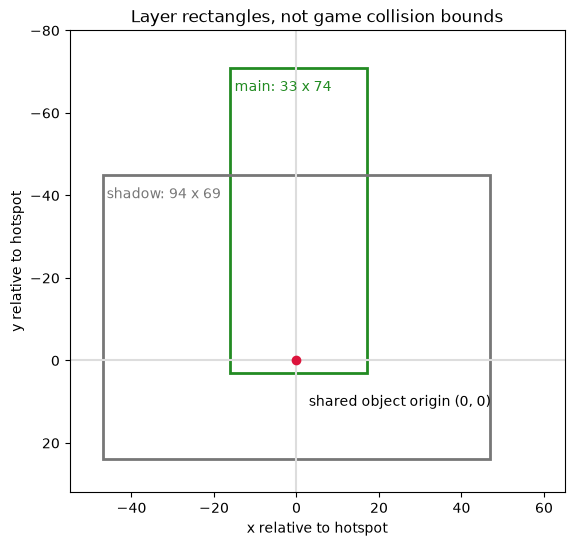

In [5]:
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(7, 6))
for name, left, top, width, height, color in [
    ('main: 33 x 74', -16, -71, 33, 74, '#228b22'),
    ('shadow: 94 x 69', -47, -45, 94, 69, '#777777'),
]:
    ax.add_patch(Rectangle((left, top), width, height, fill=False, lw=2, color=color))
    ax.text(left + 1, top + 3, name, color=color, va='top')
ax.scatter([0], [0], color='crimson', zorder=3)
ax.annotate('shared object origin (0, 0)', (0, 0), xytext=(3, 11))
ax.axhline(0, color='#dddddd'); ax.axvline(0, color='#dddddd')
ax.set_xlim(-55, 65); ax.set_ylim(32, -80); ax.set_aspect('equal')
ax.set_xlabel('x relative to hotspot'); ax.set_ylabel('y relative to hotspot')
ax.set_title('Layer rectangles, not game collision bounds')
plt.show()

## 5. 先把容器拆开：命令和像素究竟藏在哪？

我们先只读取结构，不把像素转为颜色。下面的小函数顺序走过所有帧和层，保存每段的位置。这里不会尝试从 smp_size 推断偏移，也不会按 declared_length 盲跳。

In [6]:
def read_container(blob: bytes) -> list[dict]:
    frames = []
    count = struct.unpack_from('<H', blob, 6)[0]
    pos = 32
    for i in range(count):
        start = pos
        flags, palette, smp = struct.unpack_from('<BBI', blob, pos)
        pos += 6
        layers = []
        for bit, name in enumerate(('main', 'shadow', 'outline')):
            if not flags & (1 << bit):
                continue
            layer_start = pos
            w, h, hx, hy, length, unknown = struct.unpack_from('<HHhhII', blob, pos)
            pos += 16
            edge_start = pos
            edges = [struct.unpack_from('<HH', blob, pos + 4*y) for y in range(h)]
            pos += 4*h
            lengths_start = pos
            command_size = struct.unpack_from('<I', blob, pos)[0]
            pos += 4
            pixel_size = 0
            if name == 'main':
                pixel_size = struct.unpack_from('<I', blob, pos)[0]
                pos += 4
            command_start = pos
            commands = blob[pos:pos+command_size]
            pos += command_size
            pixel_start = pos
            pixels = blob[pos:pos+pixel_size]
            pos += pixel_size
            assert pos <= len(blob)
            layers.append(dict(name=name, start=layer_start, end=pos, w=w, h=h,
                               hotspot=(hx,hy), declared_length=length, unknown=unknown,
                               edges=edges, edge_start=edge_start, lengths_start=lengths_start,
                               command_start=command_start, pixel_start=pixel_start,
                               commands=commands, pixels=pixels))
        frames.append(dict(start=start, end=pos, flags=flags, palette=palette, smp_size=smp, layers=layers))
    assert pos == len(blob), 'The entire file must be consumed.'
    return frames

frames = read_container(raw)
first = frames[0]
main, shadow = first['layers']
table(['Part', 'Start', 'End (exclusive)', 'Bytes'], [
    ('file header', 0, 32, 32),
    ('first frame header', 32, 38, 6),
    ('main header', main['start'], main['edge_start'], 16),
    ('main row edges', main['edge_start'], main['lengths_start'], 4*main['h']),
    ('main stream lengths', main['lengths_start'], main['command_start'], 8),
    ('main commands', main['command_start'], main['pixel_start'], len(main['commands'])),
    ('main packed pixels', main['pixel_start'], main['end'], len(main['pixels'])),
    ('shadow header', shadow['start'], shadow['edge_start'], 16),
    ('shadow row edges', shadow['edge_start'], shadow['lengths_start'], 4*shadow['h']),
    ('shadow stream length', shadow['lengths_start'], shadow['command_start'], 4),
    ('shadow commands + values', shadow['command_start'], shadow['end'], len(shadow['commands'])),
])

| Part | Start | End (exclusive) | Bytes |
| --- | --- | --- | --- |
| file header | 0 | 32 | 32 |
| first frame header | 32 | 38 | 6 |
| main header | 38 | 54 | 16 |
| main row edges | 54 | 350 | 296 |
| main stream lengths | 350 | 358 | 8 |
| main commands | 358 | 514 | 156 |
| main packed pixels | 514 | 2259 | 1745 |
| shadow header | 2259 | 2275 | 16 |
| shadow row edges | 2275 | 2551 | 276 |
| shadow stream length | 2551 | 2555 | 4 |
| shadow commands + values | 2555 | 4774 | 2219 |

本例的主图：16 字节层头，296 字节边界表，8 字节长度字段，156 字节命令，1,745 字节像素；总共 **2,221** 字节。层头声明的 payload 正好是后四项之和：296+8+156+1,745=2,205。

阴影：16+276+4+2,219=**2,515** 字节。第一帧因此是 6+2,221+2,515=**4,742** 字节，起点 32，加完到 4,774。这就是下一帧的位置。

主图的两个流分别回答：

- **命令流：**哪些位置透明，哪些位置画几个像素，哪里结束一行？
- **像素流：**真正画出来的像素，按绘制顺序依次使用什么调色板索引？

存储时可以把连续绘制归为一条命令，把颜色紧凑打包；不需要每个像素都重复存储自己的 x、y 和类型。

### 27 帧为什么可以完全一样？

现在已经知道每帧的实际范围，可以比较帧编码，而不猜动画。

In [7]:
frame_hashes = [hashlib.sha256(raw[f['start']:f['end']]).hexdigest() for f in frames]
table(['Observation', 'Value'], [
    ('frame records', len(frames)),
    ('distinct encoded frame contents', len(set(frame_hashes))),
    ('first frame bytes', first['end']-first['start']),
    ('file body = frame bytes x frame count', (first['end']-first['start'])*len(frames)),
])
assert smp_size == sum(f['smp_size'] for f in frames)
assert len(set(frame_hashes)) == 1

| Observation | Value |
| --- | --- |
| frame records | 27 |
| distinct encoded frame contents | 1 |
| first frame bytes | 4742 |
| file body = frame bytes x frame count | 128034 |

这个 mod 里，27 条帧记录的内容完全相同。这与把原本可能不同的树图替换成同一棵松树的效果相符。

但我们只能证明“27 条记录相同”，不能仅靠 SMX 证明原游戏把它们按怎样的方向或状态分组。这部分信息没有存进 SMX 头。即使重复内容看起来浪费，也不能随意删成一帧：外部游戏数据仍可能请求原来的帧编号。

## 6. 行边界：SMX 为什么不存满整张透明矩形？

主图矩形有 2,442 个位置，但树不是填满整个矩形的实心块。每行最左和最右往往是透明区域。SMX 用每行两个 uint16 记录它们的长度，然后只编码中间部分。

这里的 row edges 有时也被叫作 outline table。**它不是 outline 图层。**前者是所有图层都使用的行边界压缩元数据，后者是可选的独立像素掩码。

In [8]:
table(['Row y', 'Left transparent', 'Right transparent', 'Encoded middle width'], [
    (y, main['edges'][y][0], main['edges'][y][1],
     main['w']-sum(main['edges'][y]))
    for y in (0, 1, 14, 71, 73)
])

| Row y | Left transparent | Right transparent | Encoded middle width |
| --- | --- | --- | --- |
| 0 | 15 | 16 | 2 |
| 1 | 14 | 15 | 4 |
| 14 | 10 | 8 | 15 |
| 71 | 12 | 13 | 8 |
| 73 | 15 | 17 | 1 |

第 0 行的 left=15、right=16，所以在 33 个位置里，只需描述中间 33−15−16=**2** 个位置：x=15、16。行尾边界采用不包含的右端点，绘制应停在 x=17。

第 14 行的 left=10、right=8，中间宽度为 15，即 x∈[10,25)。但这不表示这 15 个位置都非透明：内部仍可能有洞，要靠命令里的 skip 描述。

对于完全空白的行，边界对为 **(65535,65535)**。解析器跳过这一行，连 EOL 都不读取。因为边界表已告诉它“这一行没有内容”，再次存一条 EOL 没有必要。不要把 65535 当作真实的像素坐标。

## 7. 命令流：像一个只会向右画的小程序

每条命令只有一字节：低两位表示操作，高六位表示 run 长度减一。非 EOL 的长度范围是 1–64。

| 低两位 | 名称 | 对当前行的效果 | 消耗主图像素槽？ |
|---|---|---|---|
| 00 | skip | 向右跳过 n 个透明位置 | 否 |
| 01 | draw | 向右画 n 个普通色像素 | 是，n 个 |
| 10 | player draw | 向右画 n 个玩家色像素 | 是，n 个 |
| 11 | EOL | 本行结束，进入下一行 | 否 |

“普通色”和“玩家色”是像素类别，不是两种不同的长度编码。普通色去该帧的调色板查色；玩家色另需选定玩家颜色，例如蓝方或红方。这个树文件没有玩家色命令，所有图像 draw 都是普通色。

先写一个十分直白的 4plus1 解包函数，拿到索引。下一节再解释它为什么这样移位。

In [9]:
def unpack_4plus1(data: bytes) -> list[int]:
    assert len(data) % 5 == 0
    indices = []
    for start in range(0, len(data), 5):
        chunk = data[start:start+5]
        sections = chunk[4]
        for i in range(4):
            index = chunk[i] | (((sections >> (2*i)) & 3) << 8)
            indices.append(index)
    return indices

slots = unpack_4plus1(main['pixels'])
print('Packed blocks:', len(main['pixels'])//5, '| available pixel slots:', len(slots))

Packed blocks: 349 | available pixel slots: 1396


现在同时走命令和像素：命令游标负责“放在哪里”，像素槽游标负责“取哪个索引”。两条游标独立，只有 draw 才让两者一起前进。

In [10]:
def decode_main_4plus1(layer: dict) -> tuple[np.ndarray, np.ndarray, list[dict], int]:
    indices = unpack_4plus1(layer['pixels'])
    image = np.full((layer['h'],layer['w']), -1, dtype=np.int32)
    pixel_types = np.zeros(image.shape, dtype=np.uint8)
    events = []
    command_pos = slot_pos = 0
    for y, (left, right) in enumerate(layer['edges']):
        if left == 65535:
            assert right == 65535
            continue
        x = left
        while True:
            start = command_pos
            byte = layer['commands'][command_pos]
            command_pos += 1
            op = byte & 3
            count = 0 if op == 3 else (byte >> 2) + 1
            events.append(dict(y=y, x=x, offset=start, byte=byte, op=op,
                               count=count, slot_start=slot_pos))
            if op == 3:
                assert x == layer['w']-right
                break
            assert x+count <= layer['w']-right
            if op in (1,2):
                assert slot_pos+count <= len(indices)
                image[y,x:x+count] = indices[slot_pos:slot_pos+count]
                pixel_types[y,x:x+count] = op
                slot_pos += count
            x += count
    assert command_pos == len(layer['commands'])
    return image, pixel_types, events, slot_pos

assert not first['flags'] & 8, 'This teaching decoder intentionally handles 4plus1.'
index_image, pixel_types, events, used_slots = decode_main_4plus1(main)
ROW = 14
row_events = [e for e in events if e['y']==ROW]
names = {0:'skip',1:'draw',2:'player draw',3:'EOL'}
table(['Command offset', 'Byte', 'Bits', 'Operation', 'Count', 'x before', 'Pixel slot before'], [
    (e['offset'], f"0x{e['byte']:02X}", f"{e['byte']:08b}",
     names[e['op']], e['count'], e['x'], e['slot_start'])
    for e in row_events
])

| Command offset | Byte | Bits | Operation | Count | x before | Pixel slot before |
| --- | --- | --- | --- | --- | --- | --- |
| 28 | 0x31 | 00110001 | draw | 13 | 10 | 131 |
| 29 | 0x00 | 00000000 | skip | 1 | 23 | 144 |
| 30 | 0x01 | 00000001 | draw | 1 | 24 | 144 |
| 31 | 0x03 | 00000011 | EOL | 0 | 25 | 145 |

把第 14 行手工执行一次：

1. 从 x=10 起，命令 **0x31=00110001**。低两位 01 是 draw，高六位 001100=12，所以画 12+1=**13** 个像素，覆盖 x=10…22。
2. 命令 **0x00** 是 skip 1，在 x=23 留一个透明洞。不从像素流取颜色。
3. 命令 **0x01** 是 draw 1，在 x=24 画一个像素。
4. 命令 **0x03** 是 EOL。此时 x=25，与 width−right=33−8=25 一致。

这一行中间的 15 个位置，只用了 **14 个像素槽**；透明洞不占颜色槽。整棵树也遵循同一原则。

**非常容易写错的一点：**像素槽游标不会在 EOL 重置；也不会把每一行补齐到四个像素。每个打包块甚至可以跨越行、draw 命令或普通色/玩家色类别边界。

In [11]:
table(['Position', 'Meaning'], [
    ('x = 0..9', 'left margin: no commands and no pixel slots'),
    ('x = 10..22', '13 drawn pixels'),
    ('x = 23', '1 skipped internal transparent position'),
    ('x = 24', '1 drawn pixel'),
    ('x = 25..32', 'right margin: no commands and no pixel slots'),
])
table(['Observation', 'Value'], [
    ('image rectangle positions', main['w']*main['h']),
    ('drawn main-image pixels', used_slots),
    ('transparent positions', int(np.count_nonzero(index_image < 0))),
    ('stored pixel slots', len(slots)),
    ('unused tail slots', len(slots)-used_slots),
])
assert used_slots == np.count_nonzero(index_image >= 0)

| Position | Meaning |
| --- | --- |
| x = 0..9 | left margin: no commands and no pixel slots |
| x = 10..22 | 13 drawn pixels |
| x = 23 | 1 skipped internal transparent position |
| x = 24 | 1 drawn pixel |
| x = 25..32 | right margin: no commands and no pixel slots |

| Observation | Value |
| --- | --- |
| image rectangle positions | 2442 |
| drawn main-image pixels | 1395 |
| transparent positions | 1047 |
| stored pixel slots | 1396 |
| unused tail slots | 1 |

## 8. 4plus1：五字节如何变成四个 10-bit 索引？

为何不是每像素一字节？因为这套主图像素表示需要从最多 **1,024** 个条目中选颜色，索引需要 10 位。8 位只能选 256 项，少了两位。

四个 10-bit 索引刚好是 40 bit，即五字节。实现把四个索引的低八位分别放在前四字节，把它们的高两位集中放到第五字节。

~~~text
byte 0: pixel 0 low 8 bits
byte 1: pixel 1 low 8 bits
byte 2: pixel 2 low 8 bits
byte 3: pixel 3 low 8 bits
byte 4: [pixel3 high2][pixel2 high2][pixel1 high2][pixel0 high2]
          bits 7..6     bits 5..4     bits 3..2     bits 1..0
~~~

所以公式是 index[i]=low[i]+256×section[i]。“section”在这里就是索引的高两位，选择四个连续的 256 项范围；它**不是颜色的 alpha、亮度或图层号**。不能仅凭这个分区推断“第 3 区都是什么材质”。

本文件第一个五字节块是 **CE CE FE 5C FF**。第五字节 FF 的四组高位都为 3，因此四个索引分别是：

- 206+3×256=**974**
- 206+3×256=**974**
- 254+3×256=**1022**
- 92+3×256=**860**

注意这里没有读取任何 RGB 值！目前得到的仍只是查表地址。

In [12]:
first_chunk = main['pixels'][:5]
table(['Slot', 'Low 8 bits', 'High 2 bits', 'Decoded palette index'], [
    (i, first_chunk[i], (first_chunk[4] >> (2*i)) & 3, slots[i])
    for i in range(4)
])
# Check that the explanation matches the actual first block.
assert slots[:4] == [974,974,1022,860]
assert len(main['pixels']) == ((used_slots+3)//4)*5

| Slot | Low 8 bits | High 2 bits | Decoded palette index |
| --- | --- | --- | --- |
| 0 | 206 | 3 | 974 |
| 1 | 206 | 3 | 974 |
| 2 | 254 | 3 | 1022 |
| 3 | 92 | 3 | 860 |

整棵树画 1,395 个主图像素：ceil(1,395/4)=349 块，349×5=**1,745** 字节。349 块能装 1,396 个索引，最后一个槽没被 draw 使用，仍实际占据文件中的位。

如果把每个索引用 uint16 保存，会要 2,790 字节。4plus1 节省的是索引表示中的多余位，并不把邻近颜色平均成一个颜色，也不会像 JPEG 那样改颜色。与此同时，行边界和 skip 又省去了透明位置的颜色数据。这是两个不同的节省来源。

## 9. 调色板：数字 30 与数字 974 怎么变成树叶颜色？

现在我们有第一个像素的索引 974，还需要查表。

~~~text
frame.palette_id = 30
           ↓ external configuration
      n_trees.pal: a table with 1024 entries
           ↓ use pixel index 974
      entry 974 → R, G, B
           ↓ place at the coordinate dictated by commands
      a colored pixel in the tree
~~~

**30 是选择哪一张表，974 是选择表中哪一项。**它们不相加、不相乘，也不是把 30 拼成索引的高位。这里实际的 palette ID 到文件名映射来自 Workshop 的 palettes.conf：

| Palette ID | 本地文件 |
|---|---|
| 20 | b_east.pal |
| 28 | b_scen.pal |
| 30 | n_trees.pal |

这说明一个关键事实：**SMX 文件不自带完整色表。**只有同一个 SMX，没有对应的调色板，你可以还原像素索引和形状，却不能唯一恢复正确颜色。随便换张表，同一个索引可能得到完全不同的色彩。

下面直接读取参考目录的表，不在 notebook 中复制 1,024 项颜色。

In [13]:
def read_palette(palette_id: int) -> tuple[str, np.ndarray]:
    mapping = {}
    for line in (PALETTE_ROOT/'palettes.conf').read_text().splitlines():
        line = line.split('//',1)[0].strip()
        if line:
            number,name = line.split(',',1)
            mapping[int(number)] = name.strip()
    name = mapping[palette_id]
    lines = (PALETTE_ROOT/name).read_text().splitlines()
    assert lines[0] == 'JASC-PAL'
    count = int(lines[2])
    entries = np.asarray([[int(v) for v in line.split()] for line in lines[3:3+count]], dtype=np.int32)
    assert len(entries) == count and entries.shape[1] >= 3
    return name,entries

palette_name, palette_entries = read_palette(first['palette'])
used_indices = np.unique(index_image[index_image >= 0])
table(['Observation', 'Value'], [
    ('frame palette ID', first['palette']),
    ('local palette file', palette_name),
    ('palette entry count', len(palette_entries)),
    ('numbers per entry', palette_entries.shape[1]),
    ('different indices used in this tree', len(used_indices)),
    ('minimum / maximum used index', f'{used_indices.min()} / {used_indices.max()}'),
])

| Observation | Value |
| --- | --- |
| frame palette ID | 30 |
| local palette file | n_trees.pal |
| palette entry count | 1024 |
| numbers per entry | 4 |
| different indices used in this tree | 37 |
| minimum / maximum used index | 449 / 1022 |

这个树使用 1,024 项表中的 **37 个不同索引**，索引范围 449–1022。并不是表中所有颜色都必须使用，也不是看到“1024 色调色板”就意味着这张树图有 1,024 种不同颜色。

索引是零起始的，第 974 项指数组下标 974，不是第 974 行文本；文本还有三行头。读色表时由 count 字段和颜色行解析，不凭文本行号猜索引。

In [14]:
table(['First pixel slot', 'Index', 'R', 'G', 'B', 'Fourth column'], [
    (i,index,*palette_entries[index].tolist())
    for i,index in enumerate(slots[:4])
])

| First pixel slot | Index | R | G | B | Fourth column |
| --- | --- | --- | --- | --- | --- |
| 0 | 974 | 30 | 33 | 17 | 255 |
| 1 | 974 | 30 | 33 | 17 | 255 |
| 2 | 1022 | 4 | 3 | 3 | 255 |
| 3 | 860 | 57 | 73 | 32 | 255 |

### 透明到底由谁控制？先不要把第四列直接叫作游戏 alpha

本地 n_trees.pal 每个条目有四个数。但深入读取本地 **Palette.java 的 loadFromFile** 后可以看到：它只把前三个数拼成 RGB；第四列不参与读取。默认 alpha=255，部分其他 palette 文件可使用它识别的 $ALPHA 指令指定统一 alpha。

因此，**复现这份 Workshop 代码的显示结果**时，我们把本例普通色像素当作不透明 RGB。第四列单独保留作观察，不能仅因有四个数就断言游戏必然把第四列当作每颜色透明度。这点也细化了前一份报告中较粗略的预览假设：存有第四列与渲染时使用它，是两件事。

此处至少需要区分三件事：

| 情况 | 从哪里判断 | 本教程如何表示 |
|---|---|---|
| 一个位置没有画任何像素 | 边界表或 skip 命令 | 索引图中的 −1 |
| 普通色像素的 RGB | palette ID 选表，再按像素索引查表 | 色表的前三列 |
| 一个阴影像素有多深 | 阴影层中的强度字节 | 黑色 alpha=强度/255，遵循 Workshop 预览 |

色表某项索引为 0，也不自动意味着透明。是否透明由该位置有没有被 draw 使用，及具体显示路径决定。另一方面，若未来换用其他工具或游戏原生色表，alpha 规则应重新核实，不能从本例推广到一切文件。

### 现在才能真正显示这棵树

下面以 Workshop 的本例 RGB 读取方式显示。左图是同一位置的索引数值图，右图才是调色板查色后的结果。左边的颜色只是 Matplotlib 用来显示数字的教学色阶，不是树的真实色表。

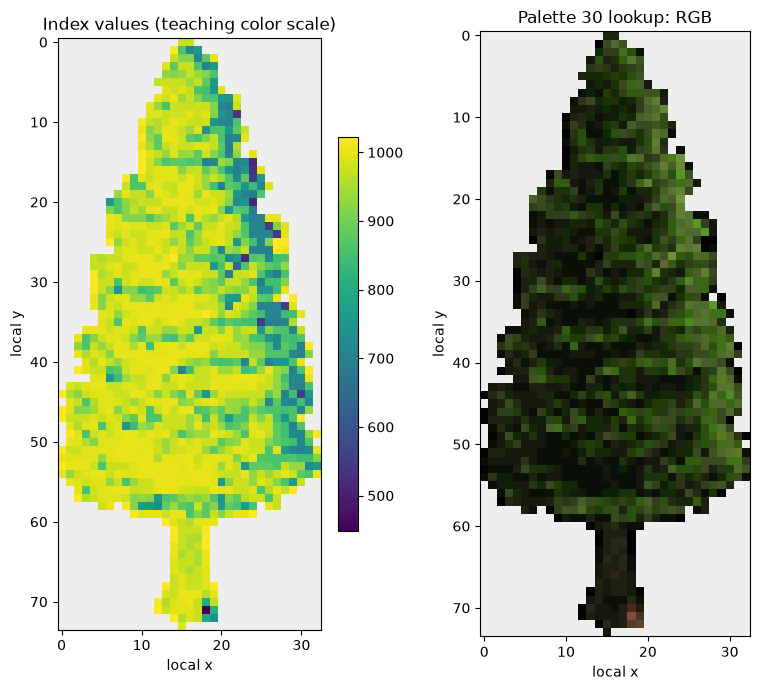

In [15]:
def rgba_from_indices(indices: np.ndarray, entries: np.ndarray) -> np.ndarray:
    rgba = np.zeros((*indices.shape,4), dtype=np.uint8)
    visible = indices >= 0
    rgba[visible,:3] = entries[indices[visible],:3]
    rgba[visible,3] = 255
    return rgba

tree_rgba = rgba_from_indices(index_image,palette_entries)
fig,axes = plt.subplots(1,2,figsize=(8,7))
masked = np.ma.masked_where(index_image < 0,index_image)
im = axes[0].imshow(masked,cmap='viridis',interpolation='nearest')
axes[0].set_title('Index values (teaching color scale)')
fig.colorbar(im,ax=axes[0],shrink=0.65)
axes[1].imshow(tree_rgba,interpolation='nearest')
axes[1].set_title('Palette 30 lookup: RGB')
for ax in axes:
    ax.set_facecolor('#eeeeee')
    ax.set_xlabel('local x'); ax.set_ylabel('local y')
plt.tight_layout(); plt.show()

### 换表不是重新画图

下面保留像素位置和每个索引，只把调色板 30 换成 28。形状不变，颜色会变；这也解释了“文件解析完全正确，颜色却很怪”的一种原因。

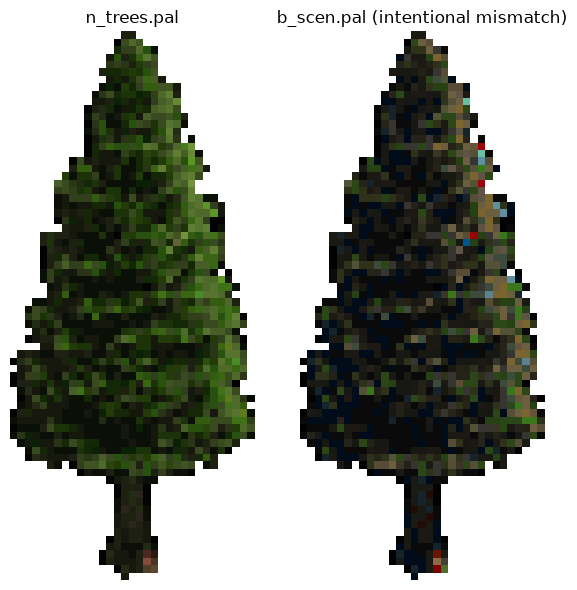

In [16]:
other_name,other_entries = read_palette(28)
assert len(other_entries) > int(used_indices.max())
fig,axes = plt.subplots(1,2,figsize=(6,6))
for ax,entries,title in [
    (axes[0],palette_entries,palette_name),
    (axes[1],other_entries,other_name + ' (intentional mismatch)'),
]:
    ax.imshow(rgba_from_indices(index_image,entries),interpolation='nearest')
    ax.set_facecolor('#eeeeee'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

### 如果将来要把新图片写成 SMX，颜色会发生什么？

解码是查表：index → RGB。编码新图则需要反过来为 RGB 选择一个可用 index。这叫颜色量化/颜色映射，不等于把 RGB 的某个字节当作索引。

若新颜色刚好在表里，可以选对应项；不在表里，则要选择近似项或采取其他已支持的素材策略。距离度量、是否考虑透明度、是否抖动，会影响效果。本教程不替你选择这些策略。SMX 的 4plus1 打包本身不丢已选索引，但“原图 → 有限调色板”的这一步可能改变颜色。

玩家色是另一条路径：命令 op=2 标记它，需要另外的玩家调色板及玩家编号。若把它当成普通 op=1，你可能固定画出某种颜色，失去红蓝阵营换色。我们的松树没有这个分支，不能用它验证全部玩家色实现。

## 10. 阴影：相同的命令外形，不同的数据组织

主图的命令流与像素流分开。阴影则只有一个流：**命令后面立刻跟强度值**。draw n 后直接读取 n 个字节，每字节一个阴影值。skip 不跟值，EOL 也不跟值。

这不是 palette 30 的索引：阴影像素存的是强度。Workshop 的 SpritePreview 用“黑色 + 此值作为 alpha”显示它。举例，值 128 约为 50% 的黑色覆盖；画到白背景会呈灰色。这里描述的是工具的可验证显示方式，不把它夸大成所有游戏场景下的混合公式。

**为什么不能对整个阴影流的每个字节都做 byte&3？**因为一旦进入 draw 的 payload，其中的字节就是强度，不是命令。例如 255 的低两位是 11，但在 payload 中它表示很深的阴影，不表示 EOL。

In [17]:
def decode_shadow(layer: dict) -> tuple[np.ndarray, list[dict]]:
    image = np.full((layer['h'],layer['w']), -1, dtype=np.int32)
    events = []
    pos = 0
    for y,(left,right) in enumerate(layer['edges']):
        if left == 65535:
            assert right == 65535
            continue
        x = left
        while True:
            start = pos
            byte = layer['commands'][pos]
            pos += 1
            op = byte & 3
            count = 0 if op == 3 else (byte >> 2)+1
            events.append(dict(y=y,x=x,offset=start,byte=byte,op=op,count=count))
            if op == 3:
                assert x == layer['w']-right
                break
            assert x+count <= layer['w']-right
            if op in (1,2):
                values = layer['commands'][pos:pos+count]
                assert len(values) == count
                image[y,x:x+count] = list(values)
                pos += count
            x += count
    assert pos == len(layer['commands'])
    return image,events

shadow_values, shadow_events = decode_shadow(shadow)
table(['Observation', 'Value'], [
    ('shadow width / height', f"{shadow['w']} / {shadow['h']}"),
    ('shadow hotspot', shadow['hotspot']),
    ('unified stream bytes', len(shadow['commands'])),
    ('fully empty rows', sum(left==65535 for left,right in shadow['edges'])),
    ('nonempty rows / EOL commands', sum(e['op']==3 for e in shadow_events)),
    ('drawn positions with value 0', int(np.count_nonzero(shadow_values==0))),
])

| Observation | Value |
| --- | --- |
| shadow width / height | 94 / 69 |
| shadow hotspot | (47, 45) |
| unified stream bytes | 2219 |
| fully empty rows | 28 |
| nonempty rows / EOL commands | 41 |
| drawn positions with value 0 | 0 |

本例阴影共有 69 行，其中 **28 行全空，41 行有命令**。这正好解释为什么 EOL 只有 41 条：全空行由边界表声明，不消费 EOL。

阴影值 0 与没有阴影像素都可能“看不见”，但存储语义不同：0 是 draw 写下的强度，空白是没有 draw 的位置。在精确重建中，不要把二者合并。

下面用自己构造的五个字节演示读指针，和 mod 素材无关：

~~~text
09 | 00 80 FF | 03
 ↑     ↑        ↑
draw3 values   EOL
~~~

0x09 的低两位是 01，高六位为 2，因此 draw 3。读取三个强度后，才把下一字节 0x03 解释为命令。

In [18]:
synthetic = bytes([0x09,0x00,0x80,0xFF,0x03])
n = (synthetic[0] >> 2)+1
assert synthetic[0]&3 == 1
values = list(synthetic[1:1+n])
assert synthetic[1+n]&3 == 3
table(['Stream role', 'Byte(s)', 'Interpretation'], [
    ('command', '09', f'draw {n}'),
    ('payload', '00 80 FF', f'intensities {values}'),
    ('command', '03', 'EOL'),
])

| Stream role | Byte(s) | Interpretation |
| --- | --- | --- |
| command | 09 | draw 3 |
| payload | 00 80 FF | intensities [0, 128, 255] |
| command | 03 | EOL |

### 放到同一个原点，才能得到完整的树

接下来分别显示主图和阴影，再把它们按锚点对齐。右下图故意忽略锚点、只对齐左上角，便于直观看出错误。

如果要比较图层，必须使用共同坐标范围。否则每张小图会自动缩放，33 像素宽的树与 94 像素宽的阴影看上去可能一样宽，反而掩盖真实关系。

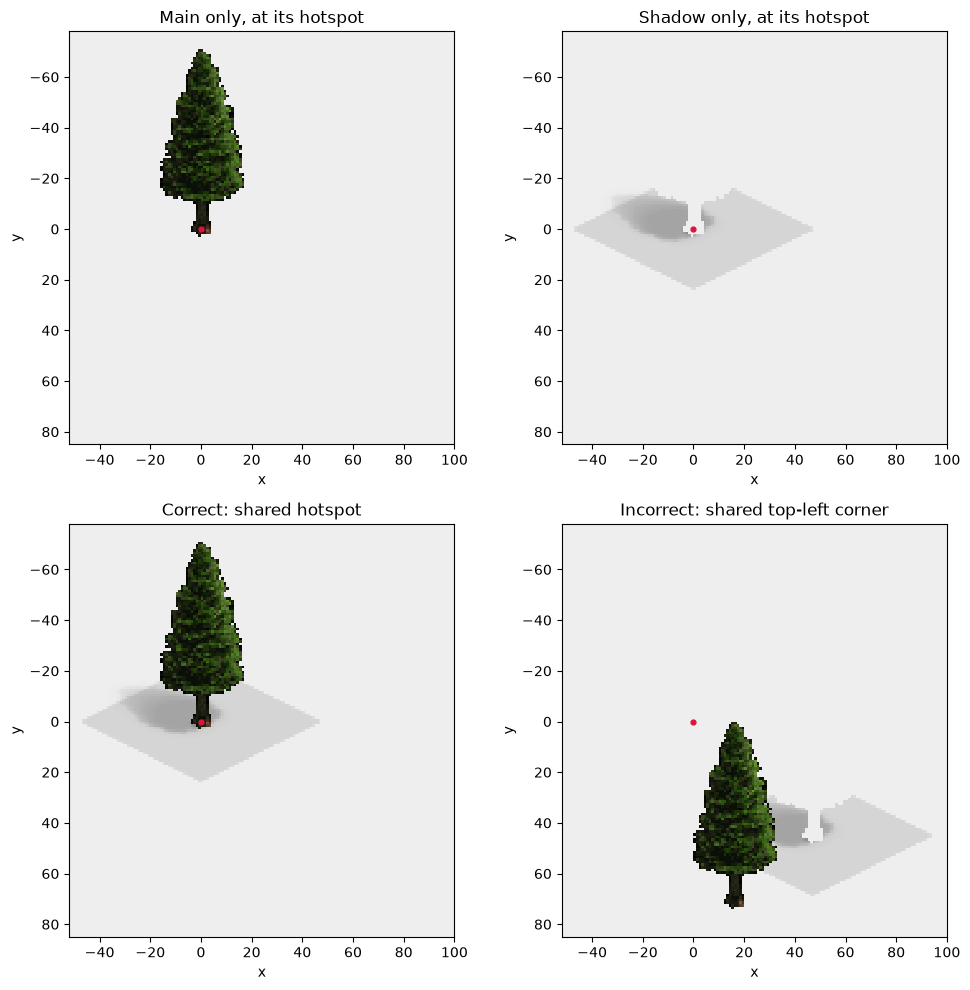

In [19]:
shadow_rgba = np.zeros((*shadow_values.shape,4), dtype=np.uint8)
present = shadow_values >= 0
shadow_rgba[present,3] = shadow_values[present].astype(np.uint8)

extent_main = (-main['hotspot'][0],main['w']-main['hotspot'][0],
               main['h']-main['hotspot'][1],-main['hotspot'][1])
extent_shadow = (-shadow['hotspot'][0],shadow['w']-shadow['hotspot'][0],
                 shadow['h']-shadow['hotspot'][1],-shadow['hotspot'][1])

fig,axes = plt.subplots(2,2,figsize=(10,10))
axes[0,0].imshow(tree_rgba,extent=extent_main,interpolation='nearest')
axes[0,0].set_title('Main only, at its hotspot')
axes[0,1].imshow(shadow_rgba,extent=extent_shadow,interpolation='nearest')
axes[0,1].set_title('Shadow only, at its hotspot')
axes[1,0].imshow(shadow_rgba,extent=extent_shadow,interpolation='nearest')
axes[1,0].imshow(tree_rgba,extent=extent_main,interpolation='nearest')
axes[1,0].set_title('Correct: shared hotspot')
axes[1,1].imshow(shadow_rgba,extent=(0,shadow['w'],shadow['h'],0),interpolation='nearest')
axes[1,1].imshow(tree_rgba,extent=(0,main['w'],main['h'],0),interpolation='nearest')
axes[1,1].set_title('Incorrect: shared top-left corner')
for ax in axes.flat:
    ax.set_facecolor('#eeeeee')
    ax.set_xlim(-52,100); ax.set_ylim(85,-78)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.scatter([0],[0],s=12,color='crimson')
plt.tight_layout(); plt.show()

## 11. 轮廓与 8to5：本例没有，但读格式时应知道它们存在

### 轮廓层是一张掩码

轮廓层也有尺寸、锚点、行边界与一个命令流。draw n 意味着“这些位置属于轮廓”，**没有随后 n 个颜色或强度值**。

它给渲染器提供一个可用单色显示的形状；本地 Workshop 用白色显示该掩码。具体什么时候、以什么颜色在游戏里展示，需要结合渲染逻辑，不能仅由 SMX 字节推断。它不是树冠边界的自动算法，也不是行边界表的另一个名字。

本例 flags 中 0x04 未设置，所以根本没有轮廓层。目标目录里的轮廓都是树桩的空占位，不能作为非空轮廓渲染的实验依据。

### 8to5 多保存了一种像素数据

本例 0x08 为零，使用四个索引压成五字节的 4plus1。另一种 8to5 则在五字节中保存**两个 10-bit 颜色索引及两个 10-bit 附加值**，本地 Workshop 将附加值称作 smudge，公开格式说明与损伤相关数据联系起来。

算一遍位数：2×(10+10)=40 bit，仍是五字节。因为多了附加数据，同样五字节只能保存两个像素，而不是四个。

它不是“树与阴影共同压在一个块里”，也不是透明度。它属于主图像素的附加信息，文件结构中仍最多是 main、shadow、outline 三层。

In [20]:
# Synthetic values, not copied from a reference sprite.
p0,p1,s0,s1 = 974,449,513,257
packed = bytes([
    p0 & 255,
    (p0 >> 8) | ((p1 & 63) << 2),
    (p1 >> 6) | ((s0 & 15) << 4),
    (s0 >> 4) | ((s1 & 3) << 6),
    s1 >> 2,
])
a,b,c,d,e = packed
decoded = (
    a | ((b & 3) << 8),
    (b >> 2) | ((c & 15) << 6),
    (c >> 4) | ((d & 63) << 4),
    (d >> 6) | (e << 2),
)
assert decoded == (p0,p1,s0,s1)
table(['Meaning', 'Input', 'Decoded'], [
    ('pixel 0 palette index',p0,decoded[0]),
    ('pixel 1 palette index',p1,decoded[1]),
    ('pixel 0 extra value',s0,decoded[2]),
    ('pixel 1 extra value',s1,decoded[3]),
])

| Meaning | Input | Decoded |
| --- | --- | --- |
| pixel 0 palette index | 974 | 974 |
| pixel 1 palette index | 449 | 449 |
| pixel 0 extra value | 513 | 513 |
| pixel 1 extra value | 257 | 257 |

保持附加值的原始 10 位很重要。Workshop 可以把它缩放成灰度用于预览，但看见一个灰度值不等于保留了原始数据；从缩放结果反推会有损失。

此处只是合成数据的编解码验证，不是本例真实文件，也不验证游戏如何根据这个附加值呈现损伤。

## 12. x1 与 x2：通过读取比较，而不是从名字猜

再读同一组 n_tree_pine_x2.smx 的第一帧。容器解析已能读取尺寸，无需先渲染整张图。

In [21]:
x2_raw = (GRAPHICS/'n_tree_pine_x2.smx').read_bytes()
x2_frames = read_container(x2_raw)
rows = []
for name, data, decoded_frames in [
    ('x1',raw,frames),('x2',x2_raw,x2_frames)
]:
    for l in decoded_frames[0]['layers']:
        rows.append((name,l['name'],f"{l['w']} x {l['h']}",l['hotspot'],len(data),len(decoded_frames)))
table(['Variant','Layer','Pixels','Hotspot','File bytes','Frames'],rows)

| Variant | Layer | Pixels | Hotspot | File bytes | Frames |
| --- | --- | --- | --- | --- | --- |
| x1 | main | 33 x 74 | (16, 71) | 128066 | 27 |
| x1 | shadow | 94 x 69 | (47, 45) | 128066 | 27 |
| x2 | main | 66 x 146 | (33, 142) | 456413 | 27 |
| x2 | shadow | 190 x 82 | (95, 34) | 456413 | 27 |

你可以观察这一对文件的实际尺寸与锚点关系。即使整体像是两套分辨率，也不能假定所有宽高都精确乘二：裁剪、空白边缘和栅格化都会影响边界。

“在头里直接把宽高改成两倍”不会把图放大，因为命令仍描述旧行数和旧位置，像素也没有变多。要真改尺寸，需要重新生成行边界、命令、像素数据以及锚点。图像缩放本身与 SMX 打包是两项工作。

## 13. 读出图像以后，为何仍不能直接丢掉原始结构？

当你已经有像素矩阵和色表，可以画出树，但“看起来一样”和“文件完全相同”是两个目标。

**视觉/像素相同：**可以重新选择命令分段，只要最后每个位置的像素类型、索引、附加值和锚点相同。例如连续 13 个普通色像素，既可用一条 draw13，也能分成 draw8+draw5。重算长度后，这两种 SMX 都能表示同样像素。

**字节相同：**必须保留原命令分段、原始 EOL 字节、memo、未知字段、声明大小及未使用槽。只保留颜色图，会丢掉这些信息。

更进一步，RGB 图本身也不足以反推所有索引：色表可能有多个条目显示同一 RGB，玩家色类别也不能从 RGB 唯一恢复。你看到的树只是结构经过渲染后的结果。

后面的附录载入上一份报告中已验证的完整解析与重建实现，与正文的教学解码器对照。此实现直接放在本 notebook 中，不导入 tmp，也不要求另外两份报告存在。

### 附录 A：完整解码与两种重建路径

这一段较长，已标为折叠输入；若你的 notebook 查看器不支持折叠，可以略过源码继续看验证结果。正文已经逐步讲过核心规则，此处补齐完整数据保留和写入实现。

parse_smx 保留字段、原命令事件、像素及剩余槽；rebuild 做精确重建。canonical_model 从 rows 重新生成流并更新大小，用于编辑后的像素等价文件。后者的 SMP 大小采用本地 Workshop writer 的计算约定，不把它冒充原生产工具的历史计算结果。

In [22]:
def unpack_pixels(data: bytes, enhanced: bool) -> list[tuple[int, int]]:
    assert len(data) % 5 == 0
    result = []
    for p in range(0, len(data), 5):
        a, b, c, d, e = data[p:p+5]
        if enhanced:
            result.extend([(a | ((b & 3) << 8), (c >> 4) | ((d & 63) << 4)),
                           ((b >> 2) | ((c & 15) << 6), (d >> 6) | (e << 2))])
        else:
            result.extend((v | (((e >> (2*i)) & 3) << 8), 0)
                          for i, v in enumerate((a,b,c,d)))
    return result

def pack_pixels(slots: list[tuple[int, int]], enhanced: bool) -> bytes:
    size = 2 if enhanced else 4
    assert len(slots) % size == 0
    out = bytearray()
    for j in range(0, len(slots), size):
        group = slots[j:j+size]
        if enhanced:
            (p,s),(q,t) = group
            out.extend([p & 255, (p >> 8) | ((q & 63) << 2),
                        (q >> 6) | ((s & 15) << 4),
                        (s >> 4) | ((t & 3) << 6), t >> 2])
        else:
            out.extend(p & 255 for p,_ in group)
            out.append(sum((p >> 8) << (2*i) for i,(p,_) in enumerate(group)))
    return bytes(out)

def decode_layer(layer: dict, enhanced: bool) -> None:
    kind = layer['kind']
    stream = layer['commands']
    slots = unpack_pixels(layer['data'], enhanced) if kind == 'main' else []
    rows, events = [], []
    pos = used = 0
    counts = Counter()
    for y,(left,right) in enumerate(layer['edges']):
        row = [None] * layer['width']
        if left == 65535 or right == 65535:
            assert left == right == 65535
            rows.append(row)
            continue
        assert left + right <= layer['width']
        x = left
        while True:
            assert pos < len(stream), (kind,y,pos)
            start = pos
            cmd = stream[pos]; pos += 1
            op, n = cmd & 3, (cmd >> 2) + 1
            counts[op] += 1
            event = {'row': y, 'x': x, 'offset': start, 'byte': cmd, 'op': op, 'count': 0 if op == 3 else n}
            if op == 3:
                assert x == layer['width'] - right, (kind,y,x,layer['width']-right)
                events.append(event)
                break
            assert x + n <= layer['width'] - right
            if op:
                if kind == 'main':
                    assert used + n <= len(slots)
                    for i in range(n):
                        row[x+i] = (op, *slots[used+i])
                    used += n
                elif kind == 'shadow':
                    assert pos + n <= len(stream)
                    for i,v in enumerate(stream[pos:pos+n]):
                        row[x+i] = (op,v)
                    pos += n
                else:
                    for i in range(n):
                        row[x+i] = (op,)
            events.append(event)
            x += n
        rows.append(row)
    assert pos == len(stream), (kind,pos,len(stream))
    if kind == 'main':
        group = 2 if enhanced else 4
        assert len(slots) >= ((used + group - 1) // group) * group
        assert pack_pixels(slots, enhanced) == layer['data']
    layer.update(rows=rows, events=events, slots=slots, used_slots=used, op_counts=dict(counts))

def parse_smx(raw: bytes) -> dict:
    pos = 0
    spans = []
    def read(fmt: str, name: str) -> tuple:
        nonlocal pos
        st = struct.Struct('<'+fmt)
        assert pos + st.size <= len(raw), name
        value = st.unpack_from(raw,pos)
        spans.append((pos,pos+st.size,name)); pos += st.size
        return value
    def take(n: int, name: str) -> bytes:
        nonlocal pos
        assert pos+n <= len(raw), name
        value=raw[pos:pos+n]
        spans.append((pos,pos+n,name)); pos += n
        return value
    signature,version,count,compressed,uncompressed,comment = read('4sHHII16s','file.header')
    assert signature == b'SMPX'
    frames=[]
    for i in range(count):
        start=pos
        flags,palette,smp_size=read('BBI',f'frame.{i}.header')
        assert flags & ~31 == 0, flags
        layers=[]
        for bit,kind in enumerate(('main','shadow','outline')):
            if not flags & (1 << bit): continue
            name=f'frame.{i}.{kind}'
            offset=pos
            w,h,hx,hy,length,unknown=read('HHhhII',name+'.header')
            edges=[read('HH',name+f'.edge.{y}') for y in range(h)]
            cl,=read('I',name+'.command_length')
            dl,=read('I',name+'.pixel_length') if kind=='main' else (0,)
            commands=take(cl,name+'.commands')
            data=take(dl,name+'.pixels') if kind=='main' else b''
            layer=dict(kind=kind,offset=offset,end=pos,width=w,height=h,hotspot=(hx,hy),
                       length=length,unknown=unknown,edges=edges,commands=commands,data=data)
            decode_layer(layer,bool(flags & 8))
            layers.append(layer)
        frames.append(dict(offset=start,end=pos,flags=flags,palette=palette,smp_size=smp_size,layers=layers))
    assert pos == len(raw), (pos,len(raw))
    cursor=0
    for a,b,_ in spans:
        assert a == cursor
        cursor=b
    assert cursor == len(raw)
    return dict(version=version,compressed=compressed,uncompressed=uncompressed,comment=comment,frames=frames,spans=spans)

def rebuild(model: dict) -> bytes:
    # Rebuild fields, commands, shadow values and every packed pixel slot.
    body=bytearray()
    for f in model['frames']:
        body.extend(struct.pack('<BBI',f['flags'],f['palette'],f['smp_size']))
        for l in f['layers']:
            stream=bytearray()
            live=[]
            for event in l['events']:
                stream.append(event['byte'])
                op,n=event['op'],event['count']
                if op in (1,2):
                    pixels=l['rows'][event['row']][event['x']:event['x']+n]
                    assert all(p[0] == op for p in pixels)
                    if l['kind']=='main': live.extend((p[1],p[2]) for p in pixels)
                    elif l['kind']=='shadow': stream.extend(p[1] for p in pixels)
            data=pack_pixels(live+l['slots'][l['used_slots']:],bool(f['flags'] & 8)) if l['kind']=='main' else b''
            edges=b''.join(struct.pack('<HH',*e) for e in l['edges'])
            sizes=struct.pack('<II',len(stream),len(data)) if l['kind']=='main' else struct.pack('<I',len(stream))
            payload=edges+sizes+stream+data
            body.extend(struct.pack('<HHhhII',l['width'],l['height'],*l['hotspot'],l['length'],l['unknown']))
            body.extend(payload)
    return struct.pack('<4sHHII16s',b'SMPX',model['version'],len(model['frames']),model['compressed'],model['uncompressed'],model['comment'])+body



def encode_rows(layer: dict, enhanced: bool) -> dict:
    # Canonical encoding from pixels, independent of original commands/edges.
    l = {k: layer[k] for k in ('kind','width','height','hotspot','unknown')}
    edges, stream, slots = [], bytearray(), []
    for row in layer['rows']:
        visible = [i for i,p in enumerate(row) if p is not None]
        if not visible:
            edges.append((65535,65535))
            continue
        left,right=visible[0],visible[-1]+1
        edges.append((left,l['width']-right))
        x=left
        while x<right:
            op=0 if row[x] is None else row[x][0]
            end=x+1
            while end<min(right,x+64) and (0 if row[end] is None else row[end][0])==op:
                end+=1
            stream.append(((end-x-1)<<2)|op)
            if op:
                if l['kind']=='main':slots.extend((p[1],p[2]) for p in row[x:end])
                elif l['kind']=='shadow':stream.extend(p[1] for p in row[x:end])
            x=end
        stream.append(3)
    group=2 if enhanced else 4
    used=len(slots)
    slots.extend([(0,0)]*((-used)%group))
    data=pack_pixels(slots,enhanced) if l['kind']=='main' else b''
    l.update(edges=edges,commands=bytes(stream),data=data,
             length=4*l['height']+(8 if l['kind']=='main' else 4)+len(stream)+len(data))
    decode_layer(l,enhanced)
    return l

def canonical_model(model: dict) -> dict:
    # SMX-Workshop size convention, not the inconsistent source convention.
    result={k:model[k] for k in ('version','comment')}
    frames=[]
    for f in model['frames']:
        layers=[encode_rows(l,bool(f['flags'] & 8)) for l in f['layers']]
        size=0
        for l in layers:
            size+=32+8*l['height']
            size+=len(l['commands'])+(4*l['used_slots'] if l['kind']=='main' else 0)
        frames.append(dict(flags=f['flags'],palette=f['palette'],smp_size=(size+63)&~63,layers=layers))
    result.update(frames=frames,uncompressed=4*len(frames)+sum(f['smp_size'] for f in frames))
    result['compressed']=sum(6+sum(16+l['length'] for l in f['layers']) for f in frames)
    return result

In [23]:
model = parse_smx(raw)
assert rebuild(model) == raw

full_main = next(l for l in model['frames'][0]['layers'] if l['kind']=='main')
full_shadow = next(l for l in model['frames'][0]['layers'] if l['kind']=='shadow')
from_tutorial = [[None if value < 0 else (int(pixel_types[y,x]),int(value),0)
                  for x,value in enumerate(row)]
                 for y,row in enumerate(index_image)]
assert from_tutorial == full_main['rows']
assert [[None if value < 0 else int(value) for value in row] for row in shadow_values] == [
    [None if pixel is None else pixel[1] for pixel in row] for row in full_shadow['rows']
]

regenerated_bytes = rebuild(canonical_model(model))
regenerated = parse_smx(regenerated_bytes)
for original_frame,new_frame in zip(model['frames'],regenerated['frames'],strict=True):
    assert (original_frame['flags'],original_frame['palette']) == (new_frame['flags'],new_frame['palette'])
    for a,b in zip(original_frame['layers'],new_frame['layers'],strict=True):
        assert (a['kind'],a['width'],a['height'],a['hotspot'],a['rows']) == (
            b['kind'],b['width'],b['height'],b['hotspot'],b['rows'])
print('Teaching decoder matches the full decoder: main and shadow.')
print('Exact byte reconstruction passed.')
print('Regenerated encoding preserves all 27 frames, pixels, dimensions and hotspots.')
print('No reference file was written.')

Teaching decoder matches the full decoder: main and shadow.
Exact byte reconstruction passed.
Regenerated encoding preserves all 27 frames, pixels, dimensions and hotspots.
No reference file was written.


### 把这棵树重新写出来，实际需要哪些信息？

现在你可以逐项回答，而不只背结构表：

| 数据 | 它解决的问题 | 丢掉后会怎样 |
|---|---|---|
| frame count 和帧记录 | 外部调用者可请求哪些素材编号 | 删帧可能使索引请求失效 |
| flags | 应该读哪些层，用哪种主图打包 | 后续字节会按错误结构解释 |
| palette ID | 索引应在哪张表中查色 | 形状正确也可能颜色错误 |
| width/height | 局部像素矩形和行数 | 不能正确走边界表和行命令 |
| hotspot | 该层相对对象原点放在哪里 | 主图与阴影错位 |
| row edges 与 skip | 哪些位置没有像素 | 图像形状和透明区域改变 |
| draw 类别与索引 | 普通色、玩家色，以及表内条目 | 换色或玩家色语义丢失 |
| shadow values | 阴影层的强度数据 | 阴影深浅丢失 |
| extra smudge（如有） | 主图附加的 10-bit 信息 | 相关显示数据丢失 |
| 原分段、剩余槽和元数据 | 精确保存原文件的表示方式 | 可视觉相同，但字节不再相同 |

此例从 offset 0 开始，到末尾 128,066，所有结构都能顺序消费；正文教学解码器和完整解析器得到相同像素，完整解析器也能逐字节重建。你因此不只是知道它“是一张树图”，还知道这张图是如何由字节构成的。

## 资料与观察依据

这份教程的具体字节规则、调色板读取和预览规则来自本地可读实现，并结合参考文件验证：

- [reference/reference.md](../../reference/reference.md)：本项目资源入口。
- [SpriteIO.java](../../reference/SMX-Workshop/src/com/imwg/smxworkshop/sprite/SpriteIO.java)：loadFromSMX、CompiledSMXFrame、saveSMXSprite，负责实际 SMX 读写。
- [Palette.java](../../reference/SMX-Workshop/src/com/imwg/smxworkshop/sprite/Palette.java)：loadFromFile，负责本地色表读取；前三列与第四列的区别以此为依据。
- [SpritePreview.java](../../reference/SMX-Workshop/src/com/imwg/smxworkshop/sprite/SpritePreview.java)：负责普通色、玩家色、阴影与轮廓的工具预览。
- [palettes.conf](../../reference/SMX-Workshop/palettes/palettes.conf)：本地 palette ID 映射。
- [openage SMX 说明](https://github.com/SFTtech/openage/blob/master/doc/media/smx-files.md)：交叉参考，2026-10-03 查阅。部分位表与本地实现不一致，正文采用实际验证的位序。

本地 SMX-Workshop checkout：ea461434f67fd8a421bedc4e383eefc5d1b5ba24。Workshop 的显示行为不自动等于所有游戏版本的渲染行为；未验证的语义已在对应段落注明，而不是用名字代替证据。

运行环境为项目的 Python 3.14.4、Jupyter、NumPy、Matplotlib。预览与原始调色板条目输出标记 transient_asset_output，交付时清除；重新运行后提交前应再次清除这些输出。素材始终从 reference 读取，不打包进 notebook。